## 1. Data

In [7]:
import random
import time

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [8]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [9]:
letters = list(sorted(set("".join(word for word in words))))

itos = {i+1:s for i,s in enumerate(letters)}
itos[0] = '.'

stoi = {s:i for i,s in itos.items()}
n_letters = len(stoi)

In [10]:
def build_dataset(words, block_size):
    X = []
    Y = []
    for word in words:
        word_padded = "." * block_size + word + '.'
        for i in range(len(word_padded) - block_size):
            x = word_padded[i:block_size + i]
            X.append([stoi[letter] for letter in x])
            Y.append(stoi[word_padded[block_size + i]])
    return torch.tensor(X), torch.tensor(Y)


random.seed(42)          # seeded so the split is the same every session
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

_splits = {}

def datasets(block_size):
    """Train/dev/test splits for a given context length, built once and cached."""
    if block_size not in _splits:
        _splits[block_size] = (
            build_dataset(words[:n1], block_size),
            build_dataset(words[n1:n2], block_size),
            build_dataset(words[n2:], block_size),
        )
    return _splits[block_size]


(Xtr, Ytr), (Xdev, Ydev), (Xte, Yte) = datasets(3)
print(f"train {tuple(Xtr.shape)}   dev {tuple(Xdev.shape)}   test {tuple(Xte.shape)}")

train (182625, 3)   dev (22655, 3)   test (22866, 3)


## 2. The model as a function of its hyperparameters

In [11]:
def make_params(block_size, embedding_dim, n_hidden, seed=0):
    g = torch.Generator().manual_seed(seed)
    fan_in = block_size * embedding_dim

    C  = torch.randn(n_letters, embedding_dim, generator=g)
    W1 = torch.randn(fan_in, n_hidden, generator=g) * (5 / 3) / fan_in ** 0.5
    b1 = torch.randn(n_hidden, generator=g) * 0.01
    W2 = torch.randn(n_hidden, n_letters, generator=g) * 0.01
    b2 = torch.zeros(n_letters)

    params = [C, W1, b1, W2, b2]
    for p in params:
        p.requires_grad = True
    return params


def forward(params, X):
    C, W1, b1, W2, b2 = params
    emb = C[X].view(X.shape[0], -1)          # (batch, block_size * embedding_dim)
    h = torch.tanh(emb @ W1 + b1)
    return h @ W2 + b2


def train(params, X, Y, steps, lr, batch_size=32, seed=0):
    g = torch.Generator().manual_seed(seed)
    lossi = []
    for i in range(steps):
        ix = torch.randint(0, X.shape[0], (batch_size,), generator=g)

        loss = F.cross_entropy(forward(params, X[ix]), Y[ix])

        for p in params:
            p.grad = None
        loss.backward()

        step_lr = lr if i < 0.8 * steps else lr * 0.1
        for p in params:
            p.data += -step_lr * p.grad

        lossi.append(loss.item())
    return lossi


@torch.no_grad()
def evaluate(params, X, Y, chunk=20000):
    """Exact loss over a whole split, chunked so wide layers don't blow up memory."""
    total = 0.0
    for i in range(0, X.shape[0], chunk):
        logits = forward(params, X[i:i + chunk])
        total += F.cross_entropy(logits, Y[i:i + chunk], reduction='sum').item()
    return total / X.shape[0]

In [ ]:
BASE = dict(               
    block_size=3,
    embedding_dim=2,
    n_hidden=100,
    lr=0.1,
    steps=20000,
    batch_size=32,
)

RESULTS = []                # one row per completed experiment


def run(seed=0, **cfg):
    """Train one model from scratch under BASE + overrides; return (train, dev) loss."""
    cfg = {**BASE, **cfg}
    (Xtr, Ytr), (Xdev, Ydev), _ = datasets(cfg['block_size'])
    params = make_params(cfg['block_size'], cfg['embedding_dim'], cfg['n_hidden'], seed=seed)
    train(params, Xtr, Ytr, cfg['steps'], cfg['lr'], cfg['batch_size'], seed=seed)
    return evaluate(params, Xtr, Ytr), evaluate(params, Xdev, Ydev)


def pick(rows, prefer_small=True):
    """Best dev loss; among values tied within the best point's seed spread, the cheapest."""
    best = min(rows, key=lambda r: r['dev'])
    if not prefer_small:
        return best
    tol = best['dev_max'] - best['dev_min']
    ties = [r for r in rows if r['dev'] <= best['dev'] + tol]
    return min(ties, key=lambda r: r['value'])


def sweep(key, values, seeds=(0, 1, 2), prefer_small=True, logx=True, **overrides):
    values = list(values)
    rows = []
    t0 = time.time()
    for v in values:
        losses = [run(seed=s, **{**overrides, key: v}) for s in seeds]
        tr = [l[0] for l in losses]
        dv = [l[1] for l in losses]
        rows.append(dict(value=v,
                         train=sum(tr) / len(tr),
                         dev=sum(dv) / len(dv),
                         dev_min=min(dv), dev_max=max(dv)))
        r = rows[-1]
        print(f"  {key} = {v!s:>8}   train {r['train']:.4f}   dev {r['dev']:.4f}"
              f"   [{r['dev_min']:.4f}, {r['dev_max']:.4f}]")

    chosen = pick(rows, prefer_small)
    print(f"\n  {len(values) * len(seeds)} runs in {time.time() - t0:.0f}s"
          f"   ->  {key} = {chosen['value']}   (dev {chosen['dev']:.4f})")

    v = [r['value'] for r in rows]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(v, [r['dev_min'] for r in rows], [r['dev_max'] for r in rows],
                    alpha=0.18, color='tab:blue', label='dev, seed spread')
    ax.plot(v, [r['train'] for r in rows], 'o--', color='tab:gray', ms=4, label='train')
    ax.plot(v, [r['dev'] for r in rows], 'o-', color='tab:blue', ms=4, label='dev')
    ax.axvline(chosen['value'], ls=':', color='tab:red', label=f"chosen = {chosen['value']}")
    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(key)
    ax.set_ylabel('cross-entropy loss')
    ax.set_title(f'{key} sweep  ({len(seeds)} seeds)')
    ax.grid(alpha=0.3)
    ax.legend()

    return dict(key=key, rows=rows, values=values,
                chosen=chosen['value'], dev=chosen['dev'])


def record(res):
    key = res['key']
    was = BASE[key]
    BASE[key] = res['chosen']
    RESULTS.append(dict(experiment=key, tried=res['values'], was=was,
                        chosen=res['chosen'], dev=res['dev']))
    print(f"BASE[{key!r}]: {was}  ->  {res['chosen']}     dev {res['dev']:.4f}")

## 3. Baseline

In [ ]:
base_train, BASELINE_DEV = run(**BASE)
print(f"baseline    train {base_train:.4f}   dev {BASELINE_DEV:.4f}")
print(f"config      {BASE}")

assert run(seed=0) == (base_train, BASELINE_DEV)

baseline    train 2.2769   dev 2.2759
config      {'block_size': 3, 'embedding_dim': 2, 'n_hidden': 100, 'lr': 0.1, 'steps': 20000, 'batch_size': 32}

reproducible: same seed -> identical losses


## 4. Experiment 1 — learning rate

  lr =     0.01   train 2.4493   dev 2.4435   [2.4364, 2.4574]
  lr =   0.0193   train 2.3817   dev 2.3783   [2.3723, 2.3840]
  lr =   0.0373   train 2.3266   dev 2.3265   [2.3204, 2.3355]
  lr =    0.072   train 2.2858   dev 2.2867   [2.2813, 2.2897]
  lr =   0.1389   train 2.2661   dev 2.2678   [2.2615, 2.2752]
  lr =   0.2683   train 2.2722   dev 2.2740   [2.2704, 2.2808]
  lr =   0.5179   train 2.3044   dev 2.3028   [2.2995, 2.3046]
  lr =      1.0   train 2.3563   dev 2.3521   [2.3441, 2.3586]

  24 runs in 58s   ->  lr = 0.1389   (dev 2.2678)


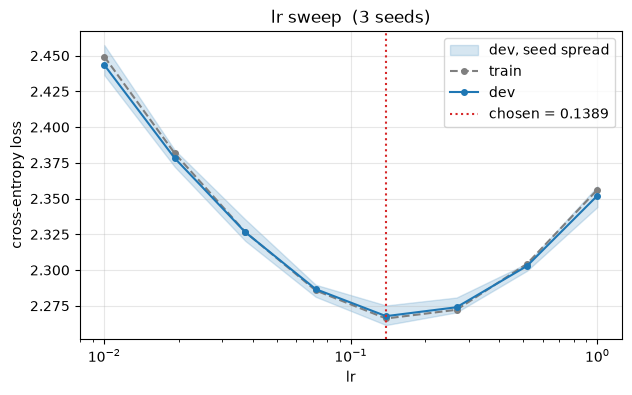

In [14]:
lr_res = sweep('lr', [round(v, 4) for v in torch.logspace(-2, 0, 8).tolist()],
               prefer_small=False)

In [15]:
record(lr_res)

BASE['lr']: 0.1  ->  0.1389     dev 2.2678


## 5. Experiment 2 — neurons in the hidden layer

  n_hidden =       10   train 2.3900   dev 2.3860   [2.3828, 2.3885]
  n_hidden =       25   train 2.3340   dev 2.3318   [2.3258, 2.3423]
  n_hidden =       50   train 2.2970   dev 2.2963   [2.2814, 2.3040]
  n_hidden =      100   train 2.2661   dev 2.2678   [2.2615, 2.2752]
  n_hidden =      200   train 2.2603   dev 2.2642   [2.2601, 2.2708]
  n_hidden =      400   train 2.2943   dev 2.2938   [2.2917, 2.2964]
  n_hidden =      700   train 2.3384   dev 2.3363   [2.3256, 2.3479]
  n_hidden =     1000   train 2.3726   dev 2.3676   [2.3659, 2.3694]

  24 runs in 58s   ->  n_hidden = 100   (dev 2.2678)


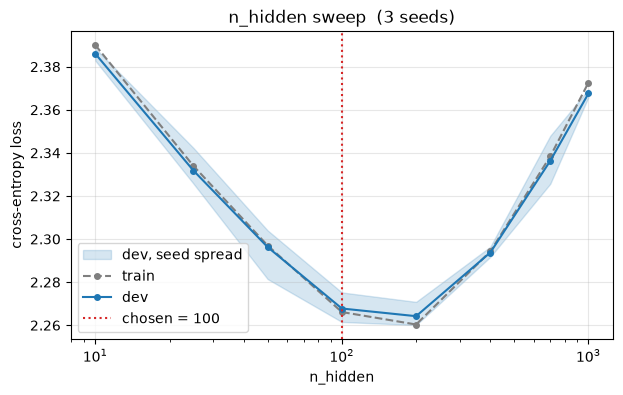

In [16]:
hidden_res = sweep('n_hidden', [10, 25, 50, 100, 200, 400, 700, 1000])

In [17]:
record(hidden_res)

BASE['n_hidden']: 100  ->  100     dev 2.2678


## 6. Experiment 3 — embedding dimension

  embedding_dim =        2   train 2.2661   dev 2.2678   [2.2615, 2.2752]
  embedding_dim =        3   train 2.2288   dev 2.2350   [2.2317, 2.2384]
  embedding_dim =        4   train 2.2100   dev 2.2208   [2.2199, 2.2223]
  embedding_dim =        6   train 2.1866   dev 2.2017   [2.1976, 2.2043]
  embedding_dim =        8   train 2.1697   dev 2.1851   [2.1838, 2.1863]
  embedding_dim =       12   train 2.1492   dev 2.1704   [2.1685, 2.1721]
  embedding_dim =       16   train 2.1347   dev 2.1595   [2.1561, 2.1624]
  embedding_dim =       24   train 2.1177   dev 2.1458   [2.1449, 2.1467]

  24 runs in 57s   ->  embedding_dim = 24   (dev 2.1458)


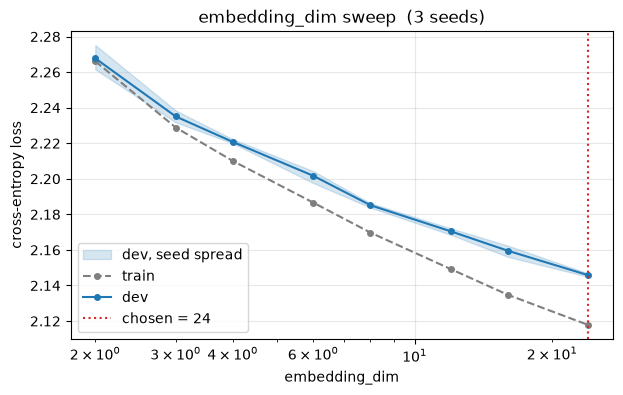

In [18]:
embed_res = sweep('embedding_dim', [2, 3, 4, 6, 8, 12, 16, 24])

In [19]:
record(embed_res)

BASE['embedding_dim']: 2  ->  24     dev 2.1458


## 7. Experiment 4 — context length

  block_size =        1   train 2.4605   dev 2.4582   [2.4579, 2.4587]
  block_size =        2   train 2.2342   dev 2.2457   [2.2446, 2.2471]
  block_size =        3   train 2.1177   dev 2.1458   [2.1449, 2.1467]
  block_size =        4   train 2.0652   dev 2.1050   [2.1033, 2.1067]
  block_size =        5   train 2.0423   dev 2.0909   [2.0876, 2.0946]
  block_size =        6   train 2.0340   dev 2.0853   [2.0830, 2.0864]

  18 runs in 47s   ->  block_size = 6   (dev 2.0853)


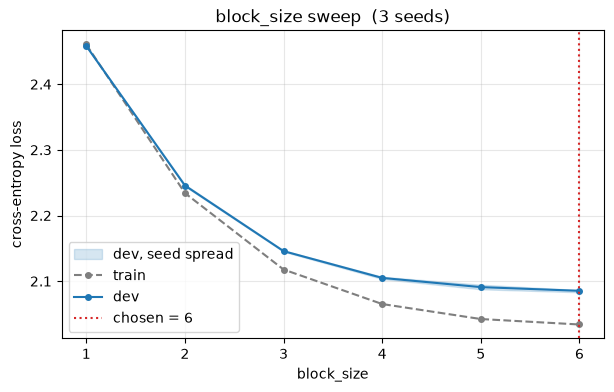

In [20]:
block_res = sweep('block_size', [1, 2, 3, 4, 5, 6], logx=False)

In [21]:
record(block_res)

BASE['block_size']: 3  ->  6     dev 2.0853


## 8. Summary

In [22]:
print(f"{'experiment':<16}{'tried':<34}{'was':>8}  ->{'chosen':>8}{'dev':>10}{'delta':>9}")
print("-" * 87)
prev = BASELINE_DEV
print(f"{'baseline':<16}{'':<34}{'':>8}    {'':>8}{BASELINE_DEV:>10.4f}{'':>9}")
for r in RESULTS:
    tried = f"{r['tried'][0]} ... {r['tried'][-1]}  ({len(r['tried'])} pts)"
    print(f"{r['experiment']:<16}{tried:<34}{r['was']!s:>8}  ->{r['chosen']!s:>8}"
          f"{r['dev']:>10.4f}{r['dev'] - prev:>+9.4f}")
    prev = r['dev']

print("-" * 87)
print(f"total improvement over baseline: {prev - BASELINE_DEV:+.4f}")
print(f"\nfinal config: {BASE}")

experiment      tried                                  was  ->  chosen       dev    delta
---------------------------------------------------------------------------------------
baseline                                                                  2.2759         
lr              0.01 ... 1.0  (8 pts)                  0.1  ->  0.1389    2.2678  -0.0081
n_hidden        10 ... 1000  (8 pts)                   100  ->     100    2.2678  +0.0000
embedding_dim   2 ... 24  (8 pts)                        2  ->      24    2.1458  -0.1220
block_size      1 ... 6  (6 pts)                         3  ->       6    2.0853  -0.0605
---------------------------------------------------------------------------------------
total improvement over baseline: -0.1906

final config: {'block_size': 6, 'embedding_dim': 24, 'n_hidden': 100, 'lr': 0.1389, 'steps': 20000, 'batch_size': 32}


## 9. Final model

In [23]:
FINAL = dict(BASE, steps=BASE['steps'] * 5)
(Xtr, Ytr), (Xdev, Ydev), (Xte, Yte) = datasets(FINAL['block_size'])

final_params = make_params(FINAL['block_size'], FINAL['embedding_dim'],
                           FINAL['n_hidden'], seed=0)
n_params = sum(p.nelement() for p in final_params)

t0 = time.time()
lossi = train(final_params, Xtr, Ytr, FINAL['steps'], FINAL['lr'],
              FINAL['batch_size'], seed=0)
print(f"{n_params} parameters, {FINAL['steps']} steps, {time.time() - t0:.0f}s\n")

print(f"train  {evaluate(final_params, Xtr, Ytr):.4f}")
print(f"dev    {evaluate(final_params, Xdev, Ydev):.4f}   (baseline {BASELINE_DEV:.4f})")
print(f"test   {evaluate(final_params, Xte, Yte):.4f}   <- read once, at the end")

17875 parameters, 100000 steps, 14s

train  1.9309
dev    2.0547   (baseline 2.2759)
test   2.0490   <- read once, at the end


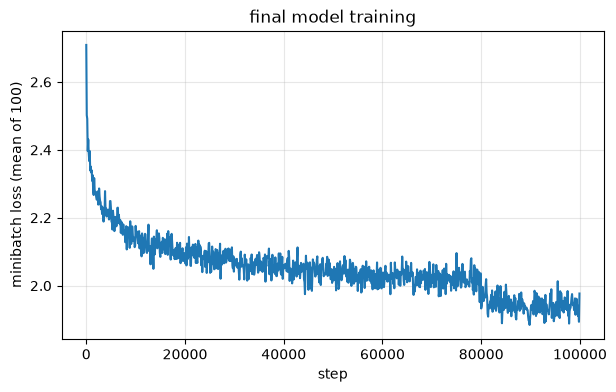

In [24]:
smoothed = torch.tensor(lossi[:len(lossi) // 100 * 100]).view(-1, 100).mean(1)
plt.figure(figsize=(7, 4))
plt.plot(torch.arange(len(smoothed)) * 100, smoothed)
plt.xlabel('step')
plt.ylabel('minibatch loss (mean of 100)')
plt.title('final model training')
plt.grid(alpha=0.3)

### Samples from the final model

In [25]:
g = torch.Generator().manual_seed(2147483647)

with torch.no_grad():
    for _ in range(20):
        out = []
        context = [0] * FINAL['block_size']
        while True:
            probs = F.softmax(forward(final_params, torch.tensor([context])), dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:
                break
        print(''.join(itos[i] for i in out))

dexzer.
jaleis.
rochi.
ahmer.
jimi.
tainella.
kamata.
kreshiah.
javer.
gotti.
morie.
cavogi.
preda.
kaley.
maside.
enkivion.
raslyn.
hucid.
avon.
lust.
